# EncoderX Internship – Task 1
## Image Classification Model using CNN

**Dataset:** CIFAR-10  
**Framework:** TensorFlow / Keras  
**Model:** Convolutional Neural Network (CNN)  
**Classes:** 10  
**Training Epochs:** 10

## 1. Dataset Loading and Exploration

The CIFAR-10 dataset was selected for this image classification task. It contains 60,000 color images distributed across 10 different classes. The dataset was loaded directly using TensorFlow/Keras.

The dataset consists of:
- 50,000 training images
- 10,000 testing images
- 10 image classes
- Image size: 32 × 32 × 3

## 2. Data Preprocessing

The images were normalized by scaling pixel values from the original range of 0–255 to the range 0–1. The training data was divided into training and validation sets using a 90:10 split while maintaining class balance.

Data augmentation was applied to the training images to improve model generalization. The augmentation techniques included:
- Random rotation up to 15 degrees
- Width shifting up to 10%
- Height shifting up to 10%
- Horizontal flipping

## 3. CNN Model Architecture

A Convolutional Neural Network (CNN) was developed using TensorFlow/Keras for CIFAR-10 image classification. The model consists of three convolutional layers with ReLU activation, followed by max-pooling layers for feature extraction and dimensionality reduction.

A fully connected Dense layer was used for classification, followed by a Dropout layer to reduce overfitting. The final layer contains 10 neurons with Softmax activation, corresponding to the 10 CIFAR-10 classes.

The CNN architecture contains:
- Three convolutional layers
- Three max-pooling layers
- One Flatten layer
- One Dense layer with 128 neurons
- Dropout with a rate of 0.5
- Final Softmax output layer with 10 classes

In [ ]:
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3015s 18us/step


In [ ]:
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [ ]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
import matplotlib.pyplot as plt

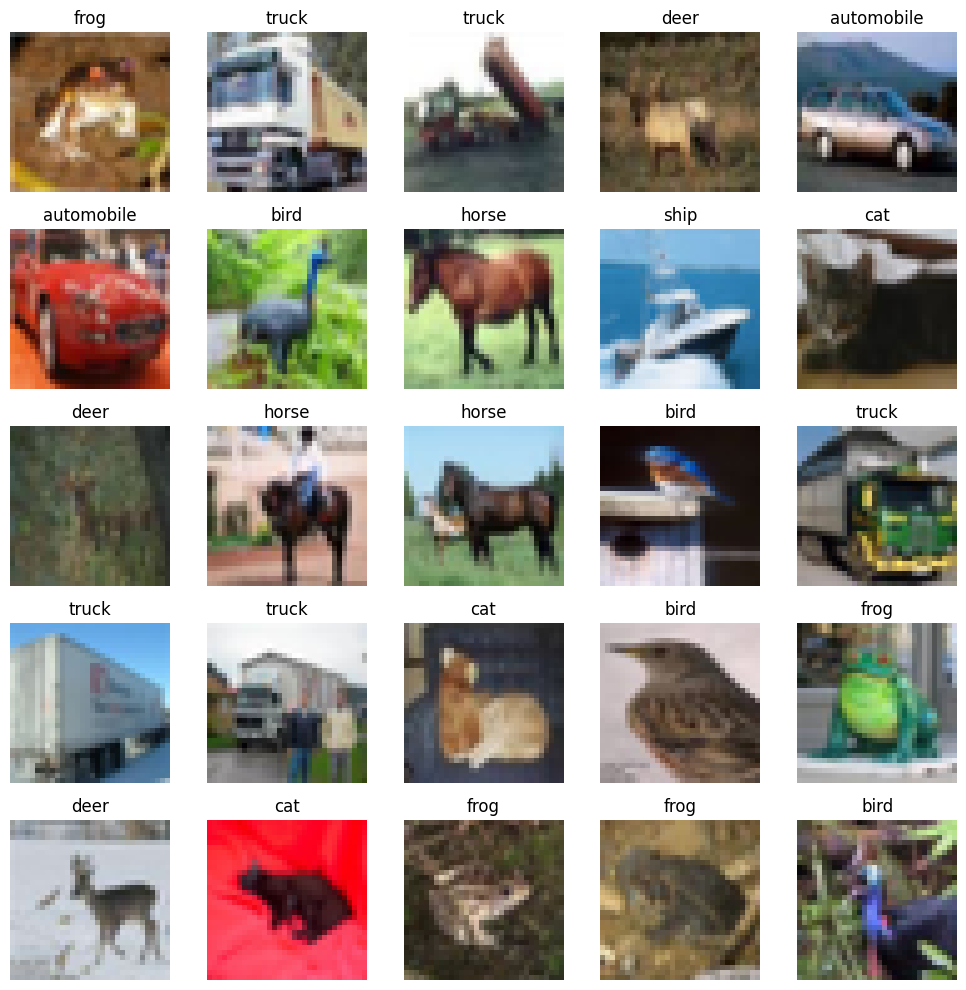

In [ ]:
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [ ]:
import numpy as np

unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{class_names[label]}: {count}")

airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000


In [ ]:
# Reload the original CIFAR-10 dataset

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values from 0-255 to 0-1

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Verify normalization

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

print("Training images:", x_train.shape)
print("Validation images:", x_val.shape)
print("Testing images:", x_test.shape)

print("Training labels:", y_train.shape)
print("Validation labels:", y_val.shape)
print("Testing labels:", y_test.shape)

Training images: (45000, 32, 32, 3)
Validation images: (5000, 32, 32, 3)
Testing images: (10000, 32, 32, 3)
Training labels: (45000, 1)
Validation labels: (5000, 1)
Testing labels: (10000, 1)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

print("Data augmentation configured successfully.")

Data augmentation configured successfully.


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
model = keras.Sequential([

    # Input layer
    layers.Input(shape=(32, 32, 3)),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification layers
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Output layer — 10 CIFAR-10 classes
    layers.Dense(10, activation="softmax")
])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Model Training

The CNN model was compiled using the Adam optimizer and sparse categorical cross-entropy loss function. The model was trained for 10 epochs using a batch size of 64.

Data augmentation was applied during training to improve generalization. The validation dataset was kept separate and was not augmented.

Training and validation accuracy and loss were recorded for every epoch to analyze the model's learning performance.

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=10,
    validation_data=(x_val, y_val)
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 126ms/step - accuracy: 0.3318 - loss: 1.7998 - val_accuracy: 0.4954 - val_loss: 1.4019
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.4598 - loss: 1.4919 - val_accuracy: 0.5302 - val_loss: 1.3130
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.5188 - loss: 1.3482 - val_accuracy: 0.5972 - val_loss: 1.1317
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.5498 - loss: 1.2693 - val_accuracy: 0.6058 - val_loss: 1.1386
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 123ms/step - accuracy: 0.5760 - loss: 1.2021 - val_accuracy: 0.6422 - val_loss: 1.0087
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.6007 - loss: 1.1471 - val_accuracy: 0.6476 - val_loss: 0.9937
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.6141 - loss: 1.0976 - val_accuracy: 0.6744 - val_loss: 0.9476
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 121ms/step - accuracy: 0.6294 - loss: 

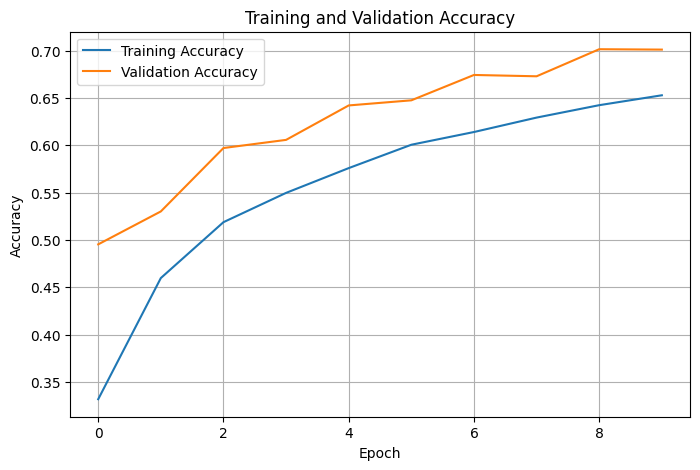

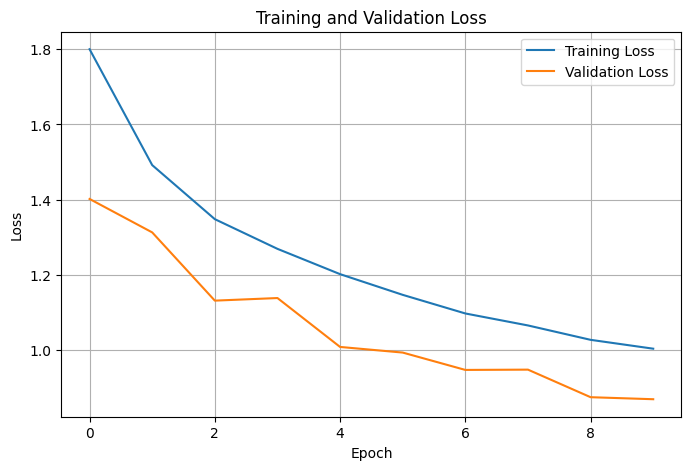

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## 5. Model Evaluation

After training, the CNN model was evaluated on the unseen CIFAR-10 test dataset. The evaluation was performed using test loss and test accuracy.

Additional classification metrics, including precision, recall, and F1-score, were calculated for each class. A confusion matrix was also generated to analyze the classification performance and identify commonly misclassified classes.

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6940 - loss: 0.8825
Test Loss: 0.8825313448905945
Test Accuracy: 0.6940000057220459


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Generate predictions for the test set
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert test labels from shape (10000, 1) to (10000,)
y_test_flat = y_test.flatten()

# Classification report
print(classification_report(
    y_test_flat,
    y_pred,
    target_names=class_names,
    digits=4
))

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step
              precision    recall  f1-score   support

    airplane     0.7867    0.7190    0.7513      1000
  automobile     0.8045    0.8270    0.8156      1000
        bird     0.8182    0.3960    0.5337      1000
         cat     0.5543    0.4290    0.4837      1000
        deer     0.6268    0.6400    0.6333      1000
         dog     0.6013    0.6350    0.6177      1000
        frog     0.7444    0.7600    0.7521      1000
       horse     0.5987    0.8400    0.6991      1000
        ship     0.8314    0.8090    0.8201      1000
       truck     0.6674    0.8850    0.7610      1000

    accuracy                         0.6940     10000
   macro avg     0.7034    0.6940    0.6868     10000
weighted avg     0.7034    0.6940    0.6868     10000



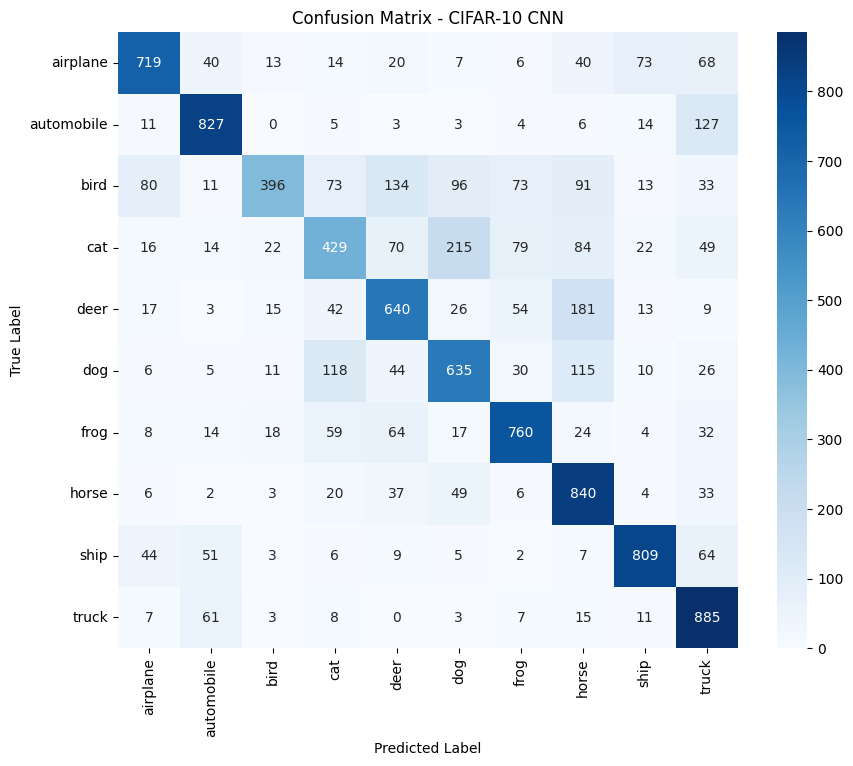

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test_flat, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - CIFAR-10 CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 6. Results and Performance Analysis

The CNN achieved a test accuracy of 69.40% on the CIFAR-10 test dataset. The macro-averaged precision, recall, and F1-score were 70.34%, 69.40%, and 68.68%, respectively.

The model performed best on the automobile and ship classes, while the cat class had the lowest F1-score. The bird class achieved relatively high precision but lower recall, indicating that several bird images were incorrectly classified as other classes.

The confusion matrix shows that visually similar classes remain challenging for the model, which is expected because CIFAR-10 images have a low resolution of 32 × 32 pixels.

## 7. Strengths, Weaknesses, and Future Improvements

### Strengths

- The CNN successfully learned meaningful visual features from the CIFAR-10 dataset.
- Data augmentation was used to improve model generalization.
- The model achieved 69.40% test accuracy.
- Precision, recall, F1-score, and a confusion matrix were used for detailed evaluation.
- The trained model was successfully saved and reloaded for prediction.

### Weaknesses

- The model has difficulty distinguishing visually similar classes, particularly cats and birds.
- CIFAR-10 images have a low resolution of 32 × 32 pixels, which limits the amount of visual detail available.
- The model was trained for only 10 epochs, so further training may improve performance.
- The CNN is relatively simple compared with modern deep learning architectures.

### Future Improvements

- Use a deeper CNN architecture with Batch Normalization.
- Apply learning-rate scheduling and early stopping.
- Tune the data augmentation parameters.
- Train for more epochs with appropriate regularization.
- Evaluate transfer-learning models such as ResNet or EfficientNet for improved classification performance.

## 8. Model Saving and Project Deliverables

In [ ]:
import os

# Create a folder for the trained model
os.makedirs("model", exist_ok=True)
s
# Save the trained CNN
model.save("model/cifar10_cnn.keras")

print("Model saved successfully!")
print("Location: model/cifar10_cnn.keras")

Model saved successfully!
Location: model/cifar10_cnn.keras


In [ ]:
from tensorflow import keras

# Load the saved model
loaded_model = keras.models.load_model("model/cifar10_cnn.keras")

# Check that it can make predictions
sample_predictions = loaded_model.predict(x_test[:5])

print("Saved model loaded successfully!")
print("Prediction shape:", sample_predictions.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
Saved model loaded successfully!
Prediction shape: (5, 10)


In [ ]:
import pandas as pd

results = {
    "Metric": [
        "Test Accuracy",
        "Test Loss",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-Score"
    ],
    "Value": [
        test_accuracy,
        test_loss,
        0.7034,
        0.6940,
        0.6868
    ]
}

results_df = pd.DataFrame(results)

# Create results folder
os.makedirs("results", exist_ok=True)

# Save results
results_df.to_csv("results/evaluation_results.csv", index=False)

print(results_df)
print("\nEvaluation results saved successfully!")

            Metric     Value
0    Test Accuracy  0.694000
1        Test Loss  0.882531
2  Macro Precision  0.703400
3     Macro Recall  0.694000
4   Macro F1-Score  0.686800

Evaluation results saved successfully!


In [ ]:
# Convert training history to a DataFrame
history_df = pd.DataFrame(history.history)

# Save training history
history_df.to_csv("results/training_history.csv", index=False)

print("Training history saved successfully!")
print("File: results/training_history.csv")
print("\nSaved columns:")
print(list(history_df.columns))

Training history saved successfully!
File: results/training_history.csv

Saved columns:
['accuracy', 'loss', 'val_accuracy', 'val_loss']


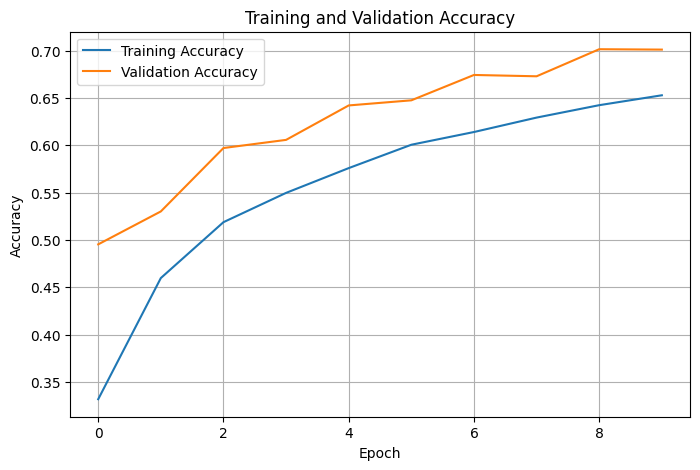

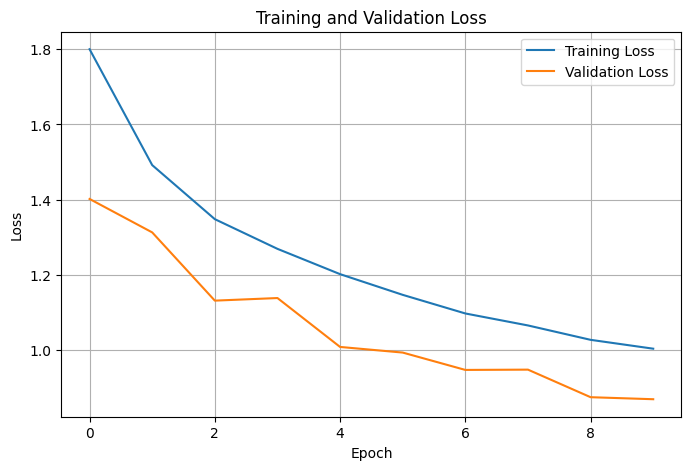

Both graphs saved successfully!


In [ ]:
# Save Training & Validation Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("results/accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# Save Training & Validation Loss graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("results/loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("Both graphs saved successfully!")

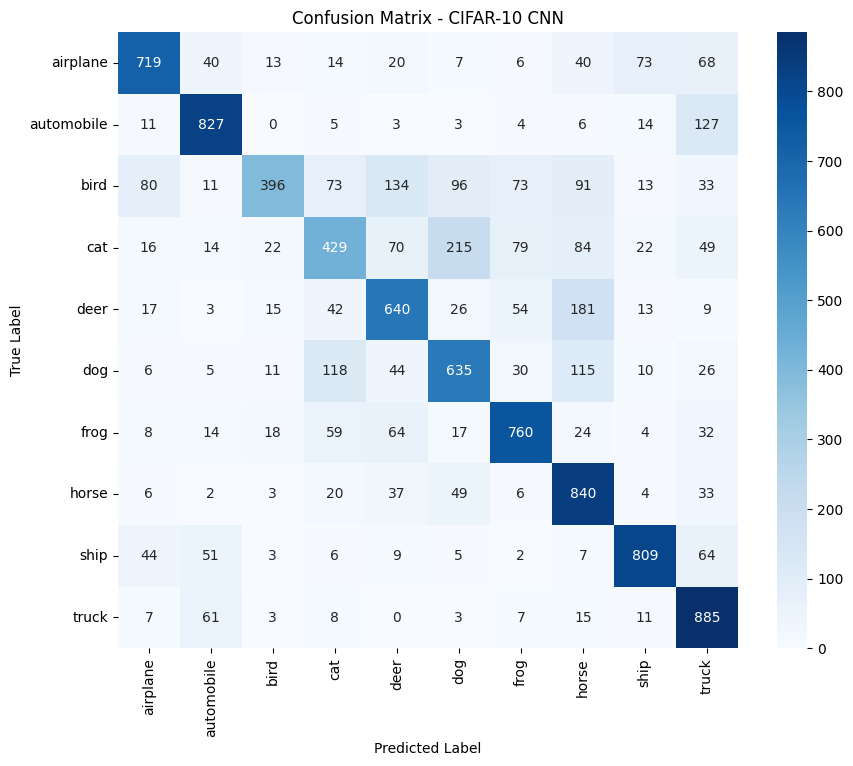

Confusion matrix saved successfully!


In [ ]:
# Create and save the confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - CIFAR-10 CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig(
    "results/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved successfully!")

In [ ]:
import os

# Create project folders
os.makedirs("model", exist_ok=True)
os.makedirs("results", exist_ok=True)

print("Project folders:")
print("✓ model/")
print("✓ results/")

print("\nFiles in model/:")
print(os.listdir("model"))

print("\nFiles in results/:")
print(os.listdir("results"))

Project folders:
✓ model/
✓ results/

Files in model/:
['cifar10_cnn.keras']

Files in results/:
['loss_curve.png', 'accuracy_curve.png', 'confusion_matrix.png', 'training_history.csv', 'evaluation_results.csv']


## 9. Conclusion
A CNN-based image classification model was successfully developed and trained using the CIFAR-10 dataset. The complete workflow included dataset exploration, preprocessing, data augmentation, CNN model development, training, and evaluation.

The model achieved a test accuracy of 69.40%, with a macro F1-score of 68.68%. The results demonstrate that the CNN can effectively classify several CIFAR-10 image categories, while visually similar classes remain challenging.

The trained model, evaluation results, training curves, and confusion matrix were saved as project deliverables. Further improvements using deeper architectures, advanced regularization, and transfer learning could potentially increase classification performance.